# LabCG3 - Eigenfaces: redimensionar, normalizar, proyección y PCA con OpenCV

Laboratorio de Visión Artificial

Dataset: **AT&T / ORL Database of Faces** (Olivetti Research Laboratory): 40 personas, 10 fotos de cada una, 92x112 en escala de grises. Lo descargué de Kaggle (`kasikrit/att-database-of-faces`) y lo dejé en `datos/att_faces/` para no depender de la descarga.

## 1. Cargar y preparar los datos

In [1]:
import cv2
import numpy as np
import os
import json
import time
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

os.makedirs('resultados', exist_ok=True)
DATASET = 'datos/att_faces'
TAM = 100          # las imágenes se llevan a 100x100 como en la guía

datos = {}         # lo que voy midiendo, para el informe
def registrar(clave, valor):
    datos[clave] = valor
    with open('resultados/datos_labcg3.json', 'w', encoding='utf-8') as f:
        json.dump(datos, f, indent=2, ensure_ascii=False, default=str)

print('OpenCV', cv2.__version__)

OpenCV 5.0.0


La función de la solución de la guía, con dos cambios chiquitos: ordeno las carpetas y las imágenes por número (`os.listdir` las devuelve en cualquier orden, y así siempre salen las mismas 5), y le paso cuántas imágenes por persona quiero para poder probar con 5 y con 10.

In [2]:
def num(nombre):
    # 's12' -> 12, '7.pgm' -> 7
    return int(''.join(c for c in nombre if c.isdigit()))

def load_faces(base_path, n_por_persona=5):
    faces = []
    labels = []

    for person in sorted(os.listdir(base_path), key=lambda p: num(p) if p.startswith('s') else 0):
        person_path = os.path.join(base_path, person)

        # OMITIR si no es una carpeta (ej: README)
        if not os.path.isdir(person_path):
            continue

        for img_name in sorted(os.listdir(person_path), key=num)[:n_por_persona]:
            img_path = os.path.join(person_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            # Validar que la imagen se leyó correctamente
            if img is not None:
                img = cv2.resize(img, (TAM, TAM))   # Redimensionar fijo
                faces.append(img.flatten())         # Aplanar a 1D (10000 dims)
                labels.append(person)

    return np.array(faces), np.array(labels)

faces, labels = load_faces(DATASET, n_por_persona=5)
print(f'{len(faces)} vectores, {len(np.unique(labels))} clases encontradas.')
print('forma de la matriz:', faces.shape, faces.dtype, '| rango:', faces.min(), '-', faces.max())

200 vectores, 40 clases encontradas.
forma de la matriz: (200, 10000) uint8 | rango: 0 - 239


Una cara de cada una de las primeras 10 personas, y cómo queda una imagen al pasar de 92x112 a 100x100:

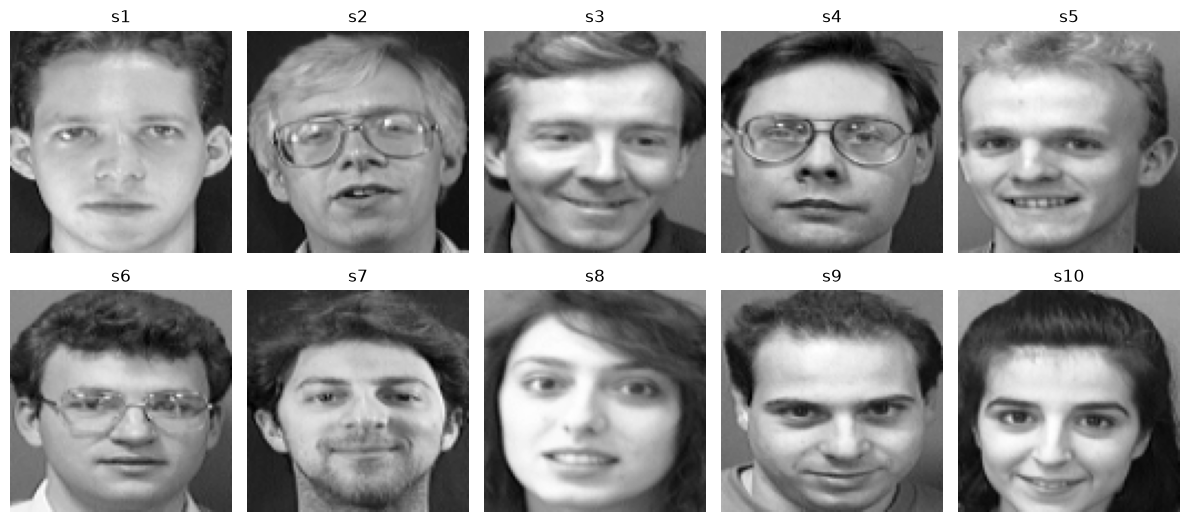

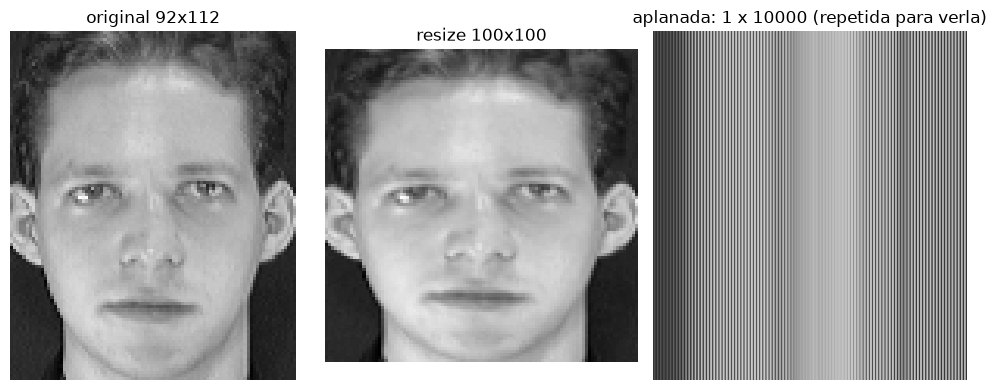

In [3]:
fig, ax = plt.subplots(2, 5, figsize=(12, 5.5))
for i, a in enumerate(ax.ravel()):
    a.imshow(faces[i * 5].reshape(TAM, TAM), cmap='gray')
    a.set_title(labels[i * 5])
    a.axis('off')
plt.tight_layout()
plt.savefig('resultados/1_muestras.png', bbox_inches='tight')
plt.show()

original = cv2.imread(os.path.join(DATASET, 's1', '1.pgm'), cv2.IMREAD_GRAYSCALE)
fig, ax = plt.subplots(1, 3, figsize=(10, 4))
ax[0].imshow(original, cmap='gray'); ax[0].set_title(f'original {original.shape[1]}x{original.shape[0]}')
ax[1].imshow(cv2.resize(original, (TAM, TAM)), cmap='gray'); ax[1].set_title('resize 100x100')
ax[2].imshow(faces[0].reshape(1, -1).repeat(12, axis=0), cmap='gray', aspect='auto')
ax[2].set_title('aplanada: 1 x 10000 (repetida para verla)')
for a in ax: a.axis('off')
plt.tight_layout()
plt.savefig('resultados/1_redimensionar_aplanar.png', bbox_inches='tight')
plt.show()

Al pasar de 92x112 a 100x100 la cara se estira un poco a lo ancho y se aplasta en lo alto (no se mantiene la proporción), pero como todas se deforman igual no importa para PCA. Lo que sí importa es que **todas tengan el mismo tamaño**, porque cada píxel pasa a ser una dimensión del vector: 100x100 = 10000 dimensiones, y la posición 5000 tiene que ser el mismo lugar de la cara en todas las fotos.

## 2. Normalización y mean face

media de faces_centered (debería ser ~0): 0.0


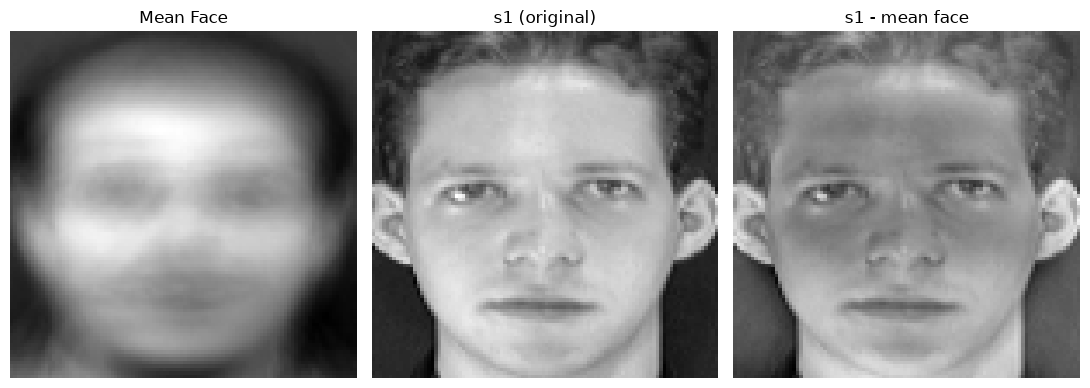

In [4]:
# Normalizar: restar media (mean centering para PCA)
mean_face = np.mean(faces, axis=0)
faces_centered = faces - mean_face

print('media de faces_centered (debería ser ~0):', faces_centered.mean().round(6))

fig, ax = plt.subplots(1, 3, figsize=(11, 4))
ax[0].imshow(mean_face.reshape(TAM, TAM), cmap='gray'); ax[0].set_title('Mean Face')
ax[1].imshow(faces[0].reshape(TAM, TAM), cmap='gray'); ax[1].set_title('s1 (original)')
ax[2].imshow(faces_centered[0].reshape(TAM, TAM), cmap='gray'); ax[2].set_title('s1 - mean face')
for a in ax: a.axis('off')
plt.tight_layout()
plt.savefig('resultados/2_mean_face.png', bbox_inches='tight')
plt.show()

La cara promedio sale borrosa pero se nota que es una cara: ojos, nariz y boca quedan en el mismo sitio porque las fotos del dataset ya vienen centradas. Al restarla, lo que queda es solo lo que hace diferente a cada persona (zonas claras = más brillante que el promedio, oscuras = menos). Eso es lo que PCA va a analizar.

## 3. PCA con OpenCV

Primero el código tal cual está en la guía:

In [5]:
try:
    pca = cv2.PCACompute(faces_centered.astype(np.float32),
                         mean=np.float32(mean_face),
                         maxComponents=50)

    fig, axs = plt.subplots(2, 5, figsize=(12, 5))
    for i in range(10):
        eigenface = pca[i].reshape(100, 100)
        axs[i//5, i%5].imshow(eigenface, cmap='gray')
        axs[i//5, i%5].set_title(f'Eigenface {i+1}')
    plt.tight_layout(); plt.show()
except Exception as e:
    plt.close('all')
    print(f'{type(e).__name__}: {e}')

print('lo que devuelve PCACompute:', type(pca), len(pca), [p.shape for p in pca])

ValueError: cannot reshape array of size 500000 into shape (100,100)
lo que devuelve PCACompute: <class 'tuple'> 2 [(10000,), (50, 10000)]


Aquí encontré dos problemas en el código de la guía:

1. **`pca[i]` no son las eigenfaces**: `cv2.PCACompute` devuelve una tupla `(mean, eigenvectors)`, no solo los eigenvectores. `pca[0]` es la media (10000 valores, por eso el reshape a 100x100 funciona y dibuja la media como si fuera la "Eigenface 1"), `pca[1]` es toda la matriz de 50x10000 y ahí revienta el reshape (ValueError), y `pca[2]` ni siquiera existe. Lo correcto es separar la tupla: `mean, eigenvectors = cv2.PCACompute(...)` y usar `eigenvectors[i]`.
2. **la media se resta dos veces**: se le pasa `faces_centered` (que ya tiene la media restada) y además `mean=mean_face`. OpenCV usa esa media para centrar otra vez, o sea que en realidad calcula PCA sobre `faces - 2*mean_face`.

Para ver si el punto 2 afecta, comparo la primera eigenface de la versión de la guía con la correcta:

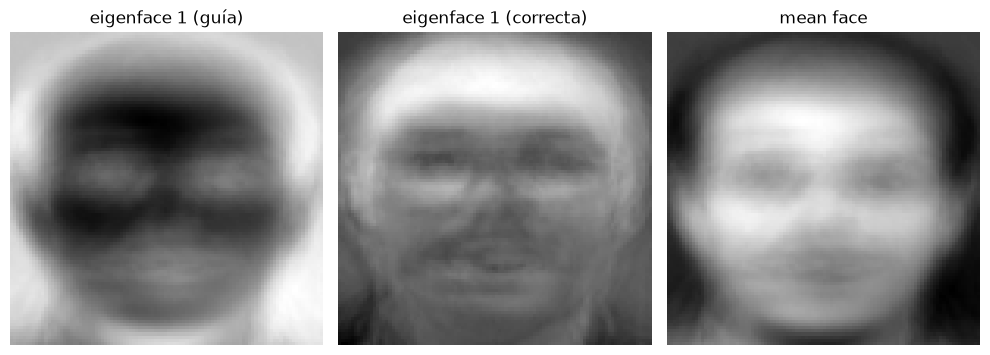

parecido con la mean face (|coseno|):
  eigenface 1 guía    : 1.0
  eigenface 1 correcta: 0.619


In [6]:
_, vecs_guia = pca                                         # versión de la guía (media restada 2 veces)
mean_cv, vecs_ok, vals_ok = cv2.PCACompute2(faces.astype(np.float32), mean=None, maxComponents=50)

fig, ax = plt.subplots(1, 3, figsize=(10, 4))
ax[0].imshow(vecs_guia[0].reshape(TAM, TAM), cmap='gray'); ax[0].set_title('eigenface 1 (guía)')
ax[1].imshow(vecs_ok[0].reshape(TAM, TAM), cmap='gray'); ax[1].set_title('eigenface 1 (correcta)')
ax[2].imshow(mean_face.reshape(TAM, TAM), cmap='gray'); ax[2].set_title('mean face')
for a in ax: a.axis('off')
plt.tight_layout()
plt.savefig('resultados/3_error_doble_media.png', bbox_inches='tight')
plt.show()

m_unit = mean_face / np.linalg.norm(mean_face)
print('parecido con la mean face (|coseno|):')
print('  eigenface 1 guía    :', abs(vecs_guia[0] @ m_unit).round(3))
print('  eigenface 1 correcta:', abs(vecs_ok[0] @ m_unit).round(3))

Con la media restada dos veces, los datos quedan todos corridos hacia `-mean_face`, entonces la dirección de "más varianza" pasa a ser la misma cara promedio (coseno = 1.0, sale como el negativo de la mean face) y la primera eigenface se desperdicia en eso. En la versión correcta la primera eigenface ya muestra variaciones de verdad.

**Versión corregida**: le paso las caras sin centrar y `mean=None` para que OpenCV calcule la media una sola vez. Uso `PCACompute2`, que es igual pero también devuelve los eigenvalores (la varianza de cada componente).

media de OpenCV igual a la de numpy: True
eigenvectors: (50, 10000) | norma de cada uno: [1. 1. 1.]


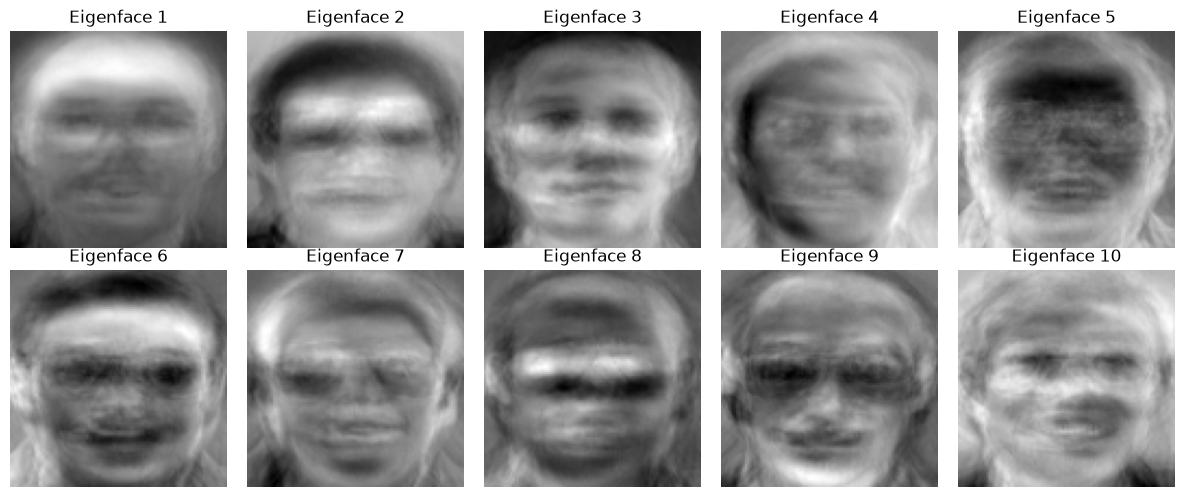

In [7]:
mean_cv, eigenvectors, eigenvalues = cv2.PCACompute2(faces.astype(np.float32), mean=None, maxComponents=50)
pca = eigenvectors            # (50, 10000): cada fila es una eigenface

print('media de OpenCV igual a la de numpy:', np.allclose(mean_cv.ravel(), mean_face, atol=1e-3))
print('eigenvectors:', eigenvectors.shape, '| norma de cada uno:', np.linalg.norm(eigenvectors, axis=1)[:3].round(3))

# Visualizar eigenfaces
fig, axs = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    eigenface = pca[i].reshape(100, 100)
    axs[i//5, i%5].imshow(eigenface, cmap='gray')
    axs[i//5, i%5].set_title(f'Eigenface {i+1}')
    axs[i//5, i%5].axis('off')
plt.tight_layout()
plt.savefig('resultados/3_eigenfaces.png', bbox_inches='tight')
plt.show()

Las eigenfaces son las "caras fantasma": cada una es una dirección en el espacio de 10000 dimensiones donde las caras varían mucho. Las primeras tienen que ver con la forma general de la cabeza, el pelo y la iluminación (la 4 es claramente luz de un lado y sombra del otro); otras marcan detalles, por ejemplo las gafas se ven muy marcadas en la 6 y la 9, y la 10 tiene la boca y el bigote.

Cuánta varianza explica cada componente (lo comparo con `sklearn.PCA`, que la guía importa):

varianza explicada por las 5 primeras (OpenCV): [0.1959 0.1305 0.0743 0.059  0.0537]
varianza explicada por las 5 primeras (sklearn): [0.1959 0.1305 0.0743 0.059  0.0537]
   10 componentes -> 64.2% de la varianza
   20 componentes -> 75.3% de la varianza
   50 componentes -> 87.9% de la varianza
  100 componentes -> 95.2% de la varianza
para 90% hacen falta 60 componentes y para 95% 98


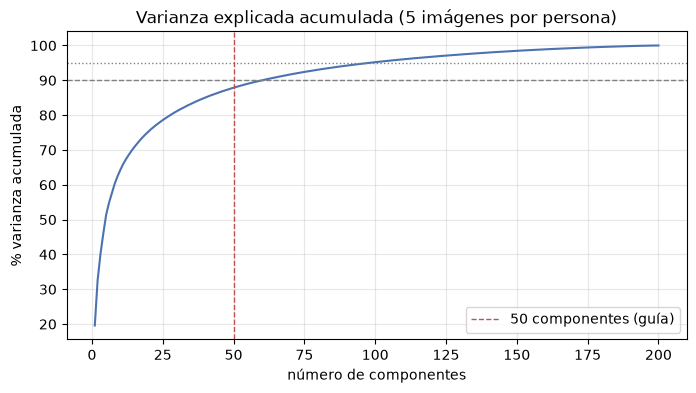

In [8]:
var_total = faces.astype(np.float64).var(axis=0).sum()
ratio_cv = eigenvalues.ravel() / var_total

pca_sk = PCA().fit(faces)
acum = np.cumsum(pca_sk.explained_variance_ratio_)

print('varianza explicada por las 5 primeras (OpenCV):', ratio_cv[:5].round(4))
print('varianza explicada por las 5 primeras (sklearn):', pca_sk.explained_variance_ratio_[:5].round(4))
for k in [10, 20, 50, 100]:
    print(f'  {k:>3} componentes -> {100*acum[k-1]:.1f}% de la varianza')
k90 = int(np.argmax(acum >= 0.90)) + 1
k95 = int(np.argmax(acum >= 0.95)) + 1
print(f'para 90% hacen falta {k90} componentes y para 95% {k95}')

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(acum) + 1), 100 * acum, color='#4C72B0')
plt.axhline(90, color='gray', ls='--', lw=1); plt.axhline(95, color='gray', ls=':', lw=1)
plt.axvline(50, color='#C44E52', ls='--', lw=1, label='50 componentes (guía)')
plt.xlabel('número de componentes'); plt.ylabel('% varianza acumulada')
plt.title('Varianza explicada acumulada (5 imágenes por persona)')
plt.legend(); plt.grid(alpha=.3)
plt.savefig('resultados/3_varianza_acumulada.png', bbox_inches='tight')
plt.show()

registrar('pca_5', {'n_imagenes': len(faces), 'var_5_primeras': ratio_cv[:5].round(4).tolist(),
                    'var_acum': {k: round(float(acum[k - 1]), 4) for k in [10, 20, 50, 100]},
                    'k90': k90, 'k95': k95})

## 4. Proyección y reconocimiento

El código de la guía hace el PCA con **todas** las caras (también las de prueba) y después divide en train/test. Eso es trampa pequeña (data leakage): las caras de prueba ya ayudaron a construir las eigenfaces. Primero lo corro como la guía y después bien (PCA solo con train), para ver si cambia. Fijo `random_state` y `stratify` para que la división sea igual siempre y haya caras de todas las personas en train.

In [9]:
# como la guía: PCA con todo y después split
X_train, X_test, y_train, y_test = train_test_split(faces_centered, labels, test_size=0.25,
                                                    random_state=42, stratify=labels)
n_components = 50
train_projected = np.dot(X_train, pca[:n_components].T)  # Proyección
test_projected = np.dot(X_test, pca[:n_components].T)

clf = SVC(kernel='rbf')
clf.fit(train_projected, y_train)
preds = clf.predict(test_projected)
acc_guia = accuracy_score(y_test, preds)
print(f'Accuracy (como la guía, SVM): {acc_guia:.2f}')
print('train:', train_projected.shape, '| test:', test_projected.shape)

Accuracy (como la guía, SVM): 0.88
train: (150, 50) | test: (50, 50)


Ahora bien hecho, todo dentro de una función para poder repetirlo con otros datos, componentes y clasificadores:

In [10]:
def entrenar_y_evaluar(faces, labels, k=50, test_size=0.25, seed=42, ruido=0.0, devolver=False):
    Xtr, Xte, ytr, yte = train_test_split(faces.astype(np.float32), labels, test_size=test_size,
                                          random_state=seed, stratify=labels)
    # PCA solo con las caras de entrenamiento
    mean, vecs = cv2.PCACompute(Xtr, mean=None, maxComponents=k)
    if ruido > 0:
        rng = np.random.default_rng(seed)
        Xte = np.clip(Xte + rng.normal(0, ruido, Xte.shape), 0, 255).astype(np.float32)
    ptr = cv2.PCAProject(Xtr, mean, vecs)          # = (Xtr - mean) @ vecs.T
    pte = cv2.PCAProject(Xte, mean, vecs)
    res = {}
    for nombre, modelo in [('SVM', SVC(kernel='rbf')), ('1-NN', KNeighborsClassifier(n_neighbors=1))]:
        modelo.fit(ptr, ytr)
        res[nombre] = accuracy_score(yte, modelo.predict(pte))
    if devolver:
        return res, dict(mean=mean, vecs=vecs, Xte=Xte, yte=yte, ptr=ptr, pte=pte, ytr=ytr)
    return res

res5, extra5 = entrenar_y_evaluar(faces, labels, k=50, devolver=True)
print(f"5 por persona, k=50 -> SVM: {res5['SVM']:.2f} | 1-NN: {res5['1-NN']:.2f}")
print(f'(como la guía daba {acc_guia:.2f})')

5 por persona, k=50 -> SVM: 0.86 | 1-NN: 0.88
(como la guía daba 0.88)


Con la misma división, hacer el PCA solo con train dio 0.86 con SVM, y como la guía (PCA con todo) 0.88. O sea, la "trampa" casi no cambia nada acá, pero en un caso real las caras de prueba no existen cuando se entrena, así que lo correcto es la versión con PCA solo en train. Con 1-NN salió 0.88.

`cv2.PCAProject` hace lo mismo que el `np.dot` de la guía pero restando la media adentro. El 1-NN (vecino más cercano con distancia euclídea) es el clasificador del método original de Eigenfaces: a cada cara de prueba le asigna la persona de la cara de entrenamiento más parecida en el espacio de eigenfaces.

Algunas predicciones de prueba (verde = bien, rojo = mal):

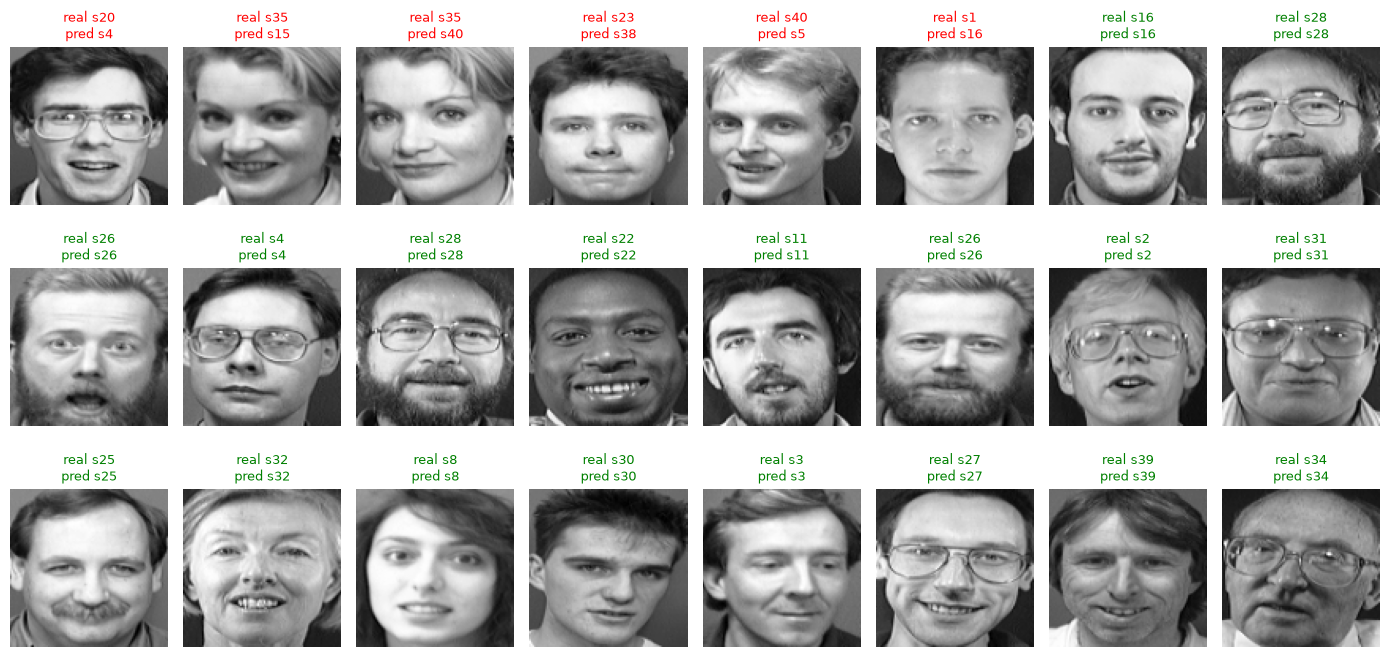

errores 1-NN: 6 de 50


In [11]:
clf1 = KNeighborsClassifier(n_neighbors=1).fit(extra5['ptr'], extra5['ytr'])
pred1 = clf1.predict(extra5['pte'])
fig, ax = plt.subplots(3, 8, figsize=(14, 7))
orden = np.argsort(pred1 == extra5['yte'])      # primero los errores
for a, i in zip(ax.ravel(), orden[:24]):
    ok = pred1[i] == extra5['yte'][i]
    a.imshow(extra5['Xte'][i].reshape(TAM, TAM), cmap='gray')
    a.set_title(f"real {extra5['yte'][i]}\npred {pred1[i]}", fontsize=9, color='green' if ok else 'red')
    a.axis('off')
plt.tight_layout()
plt.savefig('resultados/4_predicciones.png', bbox_inches='tight')
plt.show()
print('errores 1-NN:', int((pred1 != extra5['yte']).sum()), 'de', len(pred1))

### Con las 10 imágenes por persona

In [12]:
faces10, labels10 = load_faces(DATASET, n_por_persona=10)
print(f'{len(faces10)} vectores, {len(np.unique(labels10))} clases')
res10 = entrenar_y_evaluar(faces10, labels10, k=50)
print(f"10 por persona, k=50 -> SVM: {res10['SVM']:.2f} | 1-NN: {res10['1-NN']:.2f}")

# como una sola división puede tener suerte, repito con 10 divisiones distintas
SEMILLAS = range(10)
def promedio(fcs, lbs, **kw):
    r = [entrenar_y_evaluar(fcs, lbs, seed=s, **kw) for s in SEMILLAS]
    return {m: (float(np.mean([x[m] for x in r])), float(np.std([x[m] for x in r]))) for m in r[0]}

p5 = promedio(faces, labels, k=50)
p10 = promedio(faces10, labels10, k=50)
for nombre, p in [('5 por persona ', p5), ('10 por persona', p10)]:
    print(f"{nombre}: SVM {p['SVM'][0]:.3f} ± {p['SVM'][1]:.3f} | 1-NN {p['1-NN'][0]:.3f} ± {p['1-NN'][1]:.3f}")

registrar('accuracy_k50', {'guia_pca_con_todo_svm': acc_guia, 'seed42_5': res5, 'seed42_10': res10,
                           'promedio_5': p5, 'promedio_10': p10})

400 vectores, 40 clases


10 por persona, k=50 -> SVM: 0.98 | 1-NN: 0.97


5 por persona : SVM 0.920 ± 0.040 | 1-NN 0.950 ± 0.022
10 por persona: SVM 0.975 ± 0.013 | 1-NN 0.980 ± 0.008


Con 5 fotos por persona el entrenamiento tiene apenas ~3-4 caras de cada una (el 25% se va a prueba) y con 10 tiene 7-8, entonces con 10 el modelo ve más variaciones de cada persona (gestos, gafas, luz) y reconoce mejor.

## Tarea 1: número de componentes (10-100)

listo en 51.7 s
k    | 5pp SVM | 5pp 1-NN | 10pp SVM | 10pp 1-NN
5    | 0.564   | 0.840    | 0.687    | 0.834
10   | 0.836   | 0.912    | 0.898    | 0.957
20   | 0.888   | 0.932    | 0.946    | 0.970
30   | 0.904   | 0.940    | 0.967    | 0.979
40   | 0.916   | 0.950    | 0.975    | 0.977
50   | 0.920   | 0.950    | 0.975    | 0.980
60   | 0.920   | 0.950    | 0.981    | 0.979
80   | 0.926   | 0.950    | 0.980    | 0.978
100  | 0.928   | 0.950    | 0.981    | 0.980


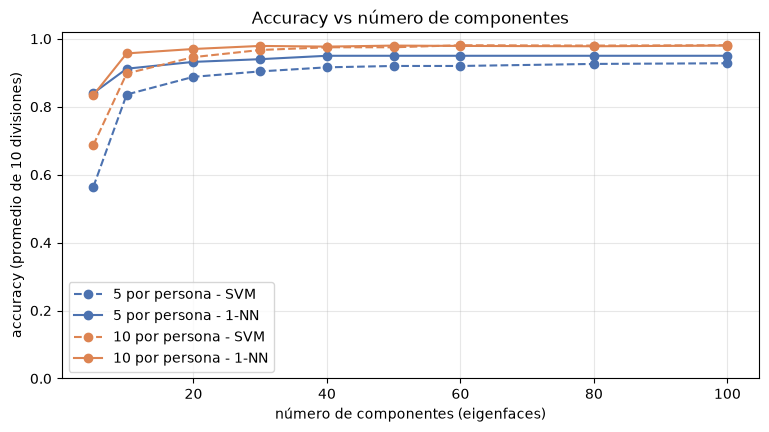

In [13]:
ks = [5, 10, 20, 30, 40, 50, 60, 80, 100]
curvas = {}
t0 = time.time()
for nombre, (fcs, lbs) in {'5 por persona': (faces, labels), '10 por persona': (faces10, labels10)}.items():
    curvas[nombre] = {k: promedio(fcs, lbs, k=k) for k in ks}
print(f'listo en {time.time() - t0:.1f} s')

print('k    | 5pp SVM | 5pp 1-NN | 10pp SVM | 10pp 1-NN')
for k in ks:
    a, b = curvas['5 por persona'][k], curvas['10 por persona'][k]
    print(f"{k:<4} | {a['SVM'][0]:.3f}   | {a['1-NN'][0]:.3f}    | {b['SVM'][0]:.3f}    | {b['1-NN'][0]:.3f}")

plt.figure(figsize=(9, 4.5))
estilos = {('5 por persona', 'SVM'): ('#4C72B0', '--'), ('5 por persona', '1-NN'): ('#4C72B0', '-'),
           ('10 por persona', 'SVM'): ('#DD8452', '--'), ('10 por persona', '1-NN'): ('#DD8452', '-')}
for (nombre, m), (c, ls) in estilos.items():
    y = [curvas[nombre][k][m][0] for k in ks]
    plt.plot(ks, y, ls, marker='o', color=c, label=f'{nombre} - {m}')
plt.xlabel('número de componentes (eigenfaces)'); plt.ylabel('accuracy (promedio de 10 divisiones)')
plt.title('Accuracy vs número de componentes'); plt.grid(alpha=.3); plt.legend()
plt.ylim(0, 1.02)
plt.savefig('resultados/t1_accuracy_vs_componentes.png', bbox_inches='tight')
plt.show()

registrar('t1_componentes', {n: {k: v for k, v in c.items()} for n, c in curvas.items()})

- Con muy pocos componentes (5) la accuracy cae bastante, sobre todo con SVM (0.56 con 5 por persona): 5 eigenfaces no alcanzan para diferenciar 40 personas.
- De 10 a ~40 sube rápido y después se estanca: con 10 por persona pasa de 0.90 a 0.975 entre 10 y 40 componentes y de ahí en adelante se queda en ~0.98. Más componentes no ayudan porque ya son detalles finos y ruido.
- 1-NN le gana a SVM con pocos componentes y es más estable. SVM con kernel rbf y los datos sin escalar necesita más dimensiones para funcionar bien.
- Con 10 fotos por persona siempre es mejor que con 5 (entre 3 y 6 puntos más).

Y cómo se ve una cara reconstruida con distintos números de componentes (lo que el modelo "ve" de la cara):

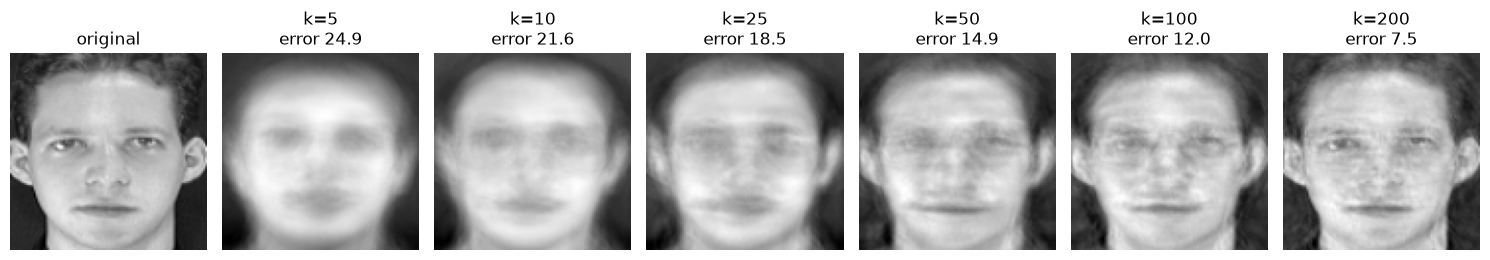

In [14]:
mean10, vecs10 = cv2.PCACompute(faces10.astype(np.float32), mean=None, maxComponents=200)
cara = faces10[0:1].astype(np.float32)
fig, ax = plt.subplots(1, 7, figsize=(15, 3))
ax[0].imshow(cara.reshape(TAM, TAM), cmap='gray'); ax[0].set_title('original')
for a, k in zip(ax[1:], [5, 10, 25, 50, 100, 200]):
    proy = cv2.PCAProject(cara, mean10, vecs10[:k])
    rec = cv2.PCABackProject(proy, mean10, vecs10[:k])
    error = np.sqrt(np.mean((rec - cara) ** 2))
    a.imshow(np.clip(rec, 0, 255).reshape(TAM, TAM), cmap='gray')
    a.set_title(f'k={k}\nerror {error:.1f}')
for a in ax: a.axis('off')
plt.tight_layout()
plt.savefig('resultados/t1_reconstruccion.png', bbox_inches='tight')
plt.show()

Con 5-10 componentes la reconstrucción es casi la cara promedio, con 50 ya se reconoce la persona y con 200 aparecen los detalles. Aunque visualmente con 50 todavía se ve borrosa, para reconocer ya alcanza: no hace falta reconstruir la cara perfecto, solo que las proyecciones de personas distintas queden separadas.

## Tarea 2: robustez al ruido gaussiano

Le sumo ruido gaussiano (media 0, desviación σ en niveles de gris 0-255) solo a las caras de prueba, con k=50, y promedio las 10 divisiones.

sigma | 5pp SVM | 5pp 1-NN | 10pp SVM | 10pp 1-NN
0     | 0.920   | 0.950    | 0.975    | 0.980
10    | 0.920   | 0.950    | 0.975    | 0.980
20    | 0.922   | 0.948    | 0.975    | 0.979
30    | 0.920   | 0.948    | 0.975    | 0.979
50    | 0.920   | 0.946    | 0.973    | 0.977
75    | 0.904   | 0.938    | 0.968    | 0.976
100   | 0.864   | 0.924    | 0.943    | 0.953


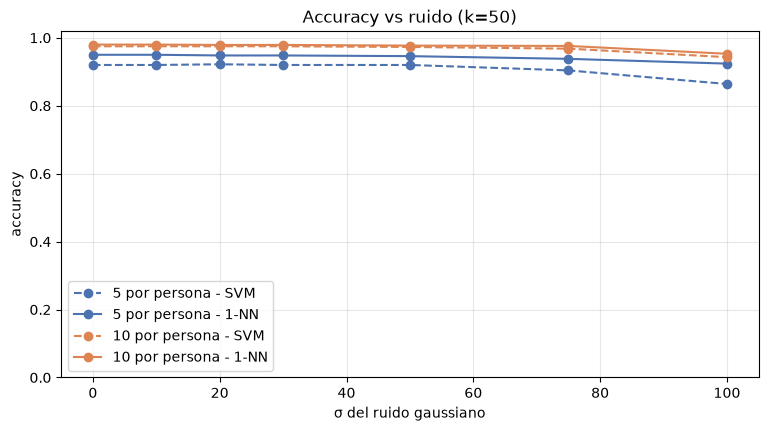

In [15]:
sigmas = [0, 10, 20, 30, 50, 75, 100]
ruido_res = {}
for nombre, (fcs, lbs) in {'5 por persona': (faces, labels), '10 por persona': (faces10, labels10)}.items():
    ruido_res[nombre] = {s: promedio(fcs, lbs, k=50, ruido=s) for s in sigmas}

print('sigma | 5pp SVM | 5pp 1-NN | 10pp SVM | 10pp 1-NN')
for s in sigmas:
    a, b = ruido_res['5 por persona'][s], ruido_res['10 por persona'][s]
    print(f"{s:<5} | {a['SVM'][0]:.3f}   | {a['1-NN'][0]:.3f}    | {b['SVM'][0]:.3f}    | {b['1-NN'][0]:.3f}")

plt.figure(figsize=(9, 4.5))
for (nombre, m), (c, ls) in estilos.items():
    plt.plot(sigmas, [ruido_res[nombre][s][m][0] for s in sigmas], ls, marker='o', color=c, label=f'{nombre} - {m}')
plt.xlabel('σ del ruido gaussiano'); plt.ylabel('accuracy'); plt.ylim(0, 1.02)
plt.title('Accuracy vs ruido (k=50)'); plt.grid(alpha=.3); plt.legend()
plt.savefig('resultados/t2_accuracy_vs_ruido.png', bbox_inches='tight')
plt.show()
registrar('t2_ruido', ruido_res)

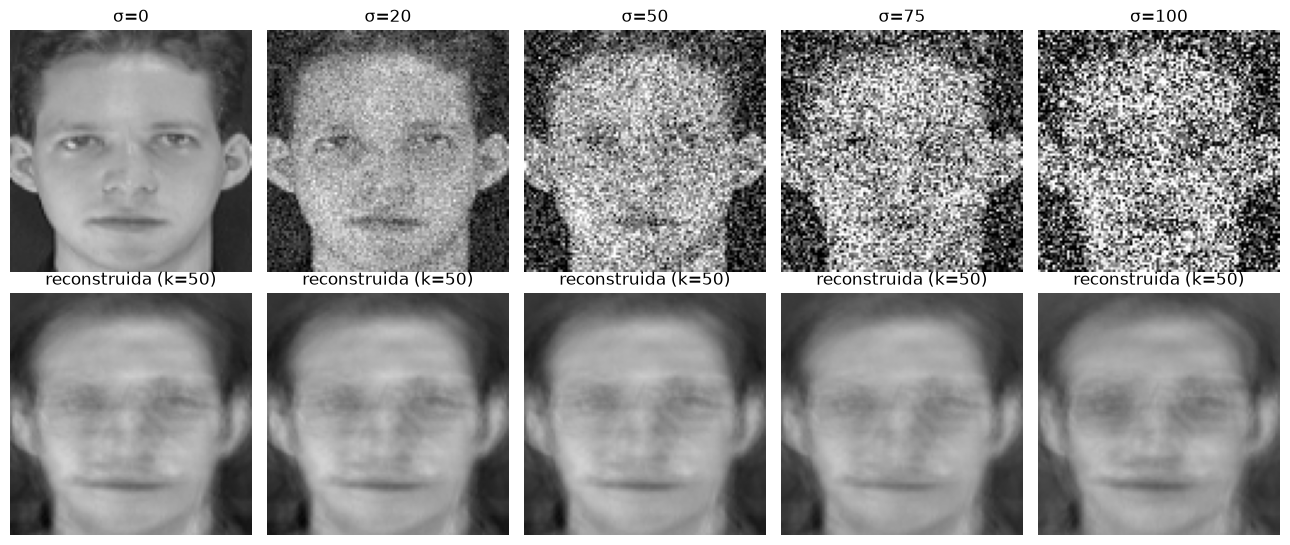

In [16]:
# cómo se ve el ruido y qué queda de la cara al proyectarla en las eigenfaces
rng = np.random.default_rng(0)
cara = faces10[0:1].astype(np.float32)
fig, ax = plt.subplots(2, 5, figsize=(13, 5.5))
for j, s in enumerate([0, 20, 50, 75, 100]):
    ruidosa = np.clip(cara + rng.normal(0, s, cara.shape), 0, 255).astype(np.float32)
    rec = cv2.PCABackProject(cv2.PCAProject(ruidosa, mean10, vecs10[:50]), mean10, vecs10[:50])
    ax[0, j].imshow(ruidosa.reshape(TAM, TAM), cmap='gray', vmin=0, vmax=255); ax[0, j].set_title(f'σ={s}')
    ax[1, j].imshow(np.clip(rec, 0, 255).reshape(TAM, TAM), cmap='gray', vmin=0, vmax=255)
    ax[1, j].set_title('reconstruida (k=50)')
for a in ax.ravel(): a.axis('off')
plt.tight_layout()
plt.savefig('resultados/t2_ruido_ejemplos.png', bbox_inches='tight')
plt.show()

Es bastante robusto: hasta σ=50 la accuracy casi no cambia (0.98 -> 0.977 con 1-NN y 10 por persona) y recién con σ=100, que ya es una imagen muy dañada, baja a ~0.95. La razón se ve en la reconstrucción: al proyectar en 50 eigenfaces el ruido se pierde casi todo, porque el ruido gaussiano se reparte en las 10000 dimensiones y las eigenfaces solo se quedan con las direcciones típicas de caras. Funciona como un filtro.

## 5. Prueba en tiempo real

Guardo el modelo (mean face, 50 eigenfaces y las proyecciones de entrenamiento con las 10 fotos por persona) para que la parte de la cámara se pueda correr sola, sin repetir todo lo anterior.

In [17]:
Xtr = faces10.astype(np.float32)
mean_face_m, pca_m = cv2.PCACompute(Xtr, mean=None, maxComponents=50)
np.savez_compressed('resultados/modelo_eigenfaces.npz', mean_face=mean_face_m.ravel(), pca=pca_m,
                    train_projected=cv2.PCAProject(Xtr, mean_face_m, pca_m), labels=labels10)
print('modelo guardado:', os.path.getsize('resultados/modelo_eigenfaces.npz') // 1024, 'KB')

modelo guardado: 1911 KB


El código de la guía con la cámara. Lo único que le agregué: cargar el modelo guardado, revisar `ret`, dibujar la ROI que usa, un límite de 30 s y guardar un frame cada 2 s. Se sale con ESC.

In [ ]:
import cv2, numpy as np, time, os, json
from sklearn.svm import SVC

m = np.load('resultados/modelo_eigenfaces.npz')
mean_face, pca = m['mean_face'], m['pca']
clf = SVC(kernel='rbf').fit(m['train_projected'], m['labels'])

cap = cv2.VideoCapture(0)
predicciones = []
guardados = 0
t0 = time.time()
while True:
    ret, frame = cap.read()
    if not ret:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    face = cv2.resize(gray[:100,:100], (100,100)).flatten()  # ROI simple
    centered = face.astype(np.float32) - mean_face
    proj = np.dot(centered, pca[:50].T)
    pred = clf.predict([proj])[0]
    predicciones.append(pred)
    cv2.rectangle(frame, (0, 0), (100, 100), (0, 255, 255), 1)   # la ROI que se está usando
    cv2.putText(frame, pred, (10,30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)
    cv2.imshow('Eigenfaces Live', frame)

    if time.time() - t0 > 2 * (guardados + 1) and guardados < 5:   # un frame cada 2 s
        guardados += 1
        cv2.imwrite(f'resultados/5_live_{guardados}.jpg', frame)
    if cv2.waitKey(1) == 27 or time.time() - t0 > 30: break
cap.release(); cv2.destroyAllWindows()

valores, cuentas = np.unique(predicciones, return_counts=True)
resumen = sorted(zip(cuentas.tolist(), valores.tolist()), reverse=True)
print(f'{len(predicciones)} frames en {time.time() - t0:.1f} s')
print('predicciones más frecuentes:', resumen[:5])
with open('resultados/5_live.json', 'w') as f:
    json.dump({'frames': len(predicciones), 'predicciones': resumen}, f, indent=2)

### Resultado con la cámara

440 frames procesados
predicciones (veces, persona): [[440, 's1']]


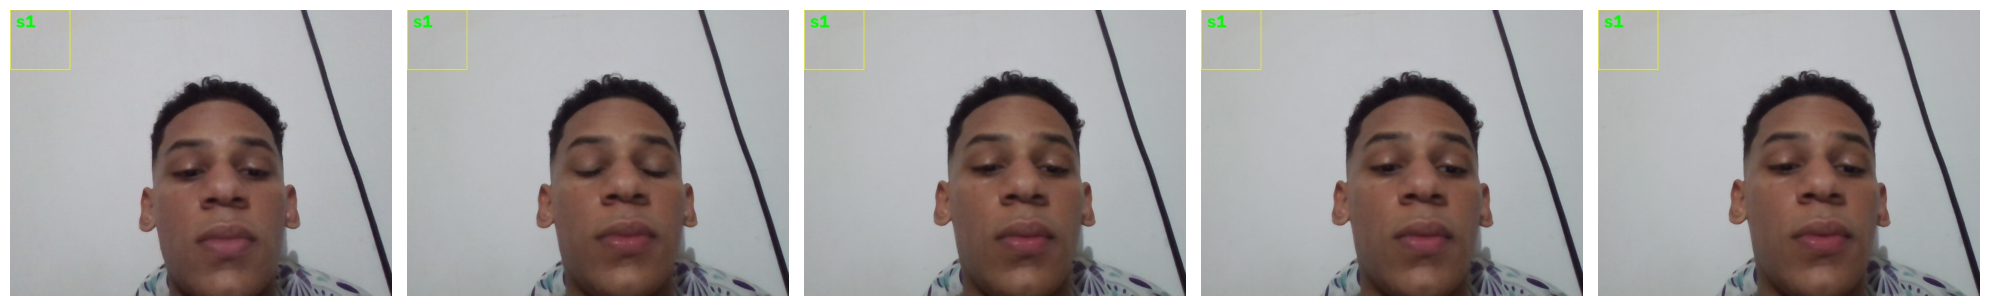

In [19]:
with open('resultados/5_live.json') as f:
    live = json.load(f)
print(f"{live['frames']} frames procesados")
print('predicciones (veces, persona):', live['predicciones'])

capturas = [cv2.imread(f'resultados/5_live_{i}.jpg') for i in range(1, 6)]
capturas = [c for c in capturas if c is not None]
fig, ax = plt.subplots(1, len(capturas), figsize=(4 * len(capturas), 3.2))
for a, c in zip(np.atleast_1d(ax), capturas):
    a.imshow(cv2.cvtColor(c, cv2.COLOR_BGR2RGB)); a.axis('off')
plt.tight_layout()
plt.savefig('resultados/5_live_capturas.png', bbox_inches='tight')
plt.show()

Los 440 frames salieron como **s1**. No es que me parezca a s1: la "ROI simple" de la guía es `gray[:100,:100]`, la esquina de arriba a la izquierda (el cuadro amarillo), y ahí solo sale la pared. El clasificador siempre tiene que escoger una de las 40 personas, entonces a una pared blanca le asigna la que queda más cerca en el espacio de eigenfaces. Además, aunque la ROI cayera en mi cara, yo no estoy en el dataset, así que también diría alguno de los 40.

Para ver qué tan lejos está esto de una cara "de verdad", tomé esos mismos frames y comparé la esquina contra mi cara recortada con el detector de rostros del lab anterior (YuNet). Mido dos cosas en el espacio de eigenfaces:
- **distancia al vecino más cercano**: qué tan cerca queda de alguna cara de entrenamiento
- **error de reconstrucción**: qué tanto se pierde al pasar la imagen por las 50 eigenfaces. Si la imagen no se parece a una cara, las eigenfaces no la pueden representar y el error es grande.

Como referencia uso caras del dataset que el modelo no vio (PCA con 300 caras y prueba con las otras 100).

caras del dataset no vistas: distancia NN 1353 (máx 2808) | error reconstrucción 18.0 (máx 25.2) | accuracy 0.98
esquina (guía) : 5 imágenes | distancia NN 5095 | error reconstrucción 16.9 | pred ['s1', 's1', 's1', 's1', 's1']
cara recortada : 5 imágenes | distancia NN 2692 | error reconstrucción 23.3 | pred ['s39', 's29', 's39', 's29', 's29']


[ WARN:0@117.072] global net_impl_backend.cpp:345 setPreferableTarget Targets are not supported by the new graph engine for now


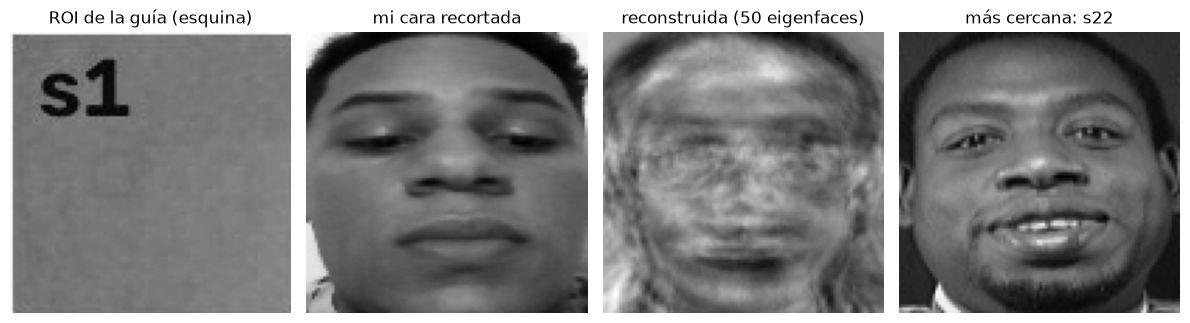

In [20]:
from sklearn.neighbors import NearestNeighbors

Xtr_r, Xte_r, ytr_r, yte_r = train_test_split(faces10.astype(np.float32), labels10, test_size=0.25,
                                              random_state=42, stratify=labels10)
mean_r, vecs_r = cv2.PCACompute(Xtr_r, mean=None, maxComponents=50)
ptr_r = cv2.PCAProject(Xtr_r, mean_r, vecs_r)
nn = NearestNeighbors(n_neighbors=1).fit(ptr_r)
svm_r = SVC(kernel='rbf').fit(ptr_r, ytr_r)

def medir(vectores):
    p = cv2.PCAProject(vectores, mean_r, vecs_r)
    rec = cv2.PCABackProject(p, mean_r, vecs_r)
    dist, idx = nn.kneighbors(p)
    error = np.sqrt(((vectores - rec) ** 2).mean(axis=1))
    return dist.ravel(), error, svm_r.predict(p), idx.ravel(), rec

d_ref, e_ref, pred_ref, _, _ = medir(Xte_r)
print(f'caras del dataset no vistas: distancia NN {d_ref.mean():.0f} (máx {d_ref.max():.0f}) | '
      f'error reconstrucción {e_ref.mean():.1f} (máx {e_ref.max():.1f}) | accuracy {accuracy_score(yte_r, pred_ref):.2f}')

detector = cv2.FaceDetectorYN.create('modelos/face_detection_yunet_2023mar.onnx', '', (640, 480), 0.8)
esquinas, caras = [], []
for c in capturas:
    gray = cv2.cvtColor(c, cv2.COLOR_BGR2GRAY)
    esquinas.append(cv2.resize(gray[:100, :100], (TAM, TAM)))
    detector.setInputSize((c.shape[1], c.shape[0]))
    _, det = detector.detect(c)
    if det is not None:
        x, y, w, h = [int(v) for v in det[0][:4]]
        x, y = max(x, 0), max(y, 0)
        caras.append(cv2.resize(gray[y:y + h, x:x + w], (TAM, TAM)))

resultados_live = {}
for nombre, imgs in [('esquina (guía)', esquinas), ('cara recortada', caras)]:
    V = np.array([i.flatten() for i in imgs], np.float32)
    d, e, pr, idx, rec = medir(V)
    resultados_live[nombre] = {'n': len(imgs), 'dist_nn': round(float(d.mean()), 1), 'error_rec': round(float(e.mean()), 1),
                               'predicciones': pr.tolist()}
    print(f'{nombre:<15}: {len(imgs)} imágenes | distancia NN {d.mean():.0f} | error reconstrucción {e.mean():.1f} | pred {pr.tolist()}')
    if nombre == 'cara recortada':
        rec_cara, idx_cara = rec, idx

registrar('5_live', {'json': live, 'referencia_dataset': {'dist_nn': round(float(d_ref.mean()), 1),
                     'dist_nn_max': round(float(d_ref.max()), 1), 'error_rec': round(float(e_ref.mean()), 1),
                     'error_rec_max': round(float(e_ref.max()), 1)}, 'capturas': resultados_live})

fig, ax = plt.subplots(1, 4, figsize=(12, 3.4))
ax[0].imshow(esquinas[0], cmap='gray'); ax[0].set_title('ROI de la guía (esquina)')
ax[1].imshow(caras[0], cmap='gray'); ax[1].set_title('mi cara recortada')
ax[2].imshow(np.clip(rec_cara[0], 0, 255).reshape(TAM, TAM), cmap='gray'); ax[2].set_title('reconstruida (50 eigenfaces)')
ax[3].imshow(Xtr_r[idx_cara[0]].reshape(TAM, TAM), cmap='gray'); ax[3].set_title(f'más cercana: {ytr_r[idx_cara[0]]}')
for a in ax: a.axis('off')
plt.tight_layout()
plt.savefig('resultados/5_analisis_live.png', bbox_inches='tight')
plt.show()

(Las capturas se guardaron después de dibujar el cuadro y el texto, por eso en la esquina aparece "s1". En vivo el modelo veía solo la pared, pero para esta comparación da igual: sigue sin ser una cara.)

- **La esquina** queda a una distancia de ~5100 de la cara de entrenamiento más cercana, casi el doble de la distancia máxima de una cara del dataset que el modelo no había visto (~2800). Su error de reconstrucción es bajo, pero solo porque es una zona casi lisa y la cara promedio ya la representa bien. Aun así, el SVM la pone en s1 porque siempre tiene que escoger a alguien.
- **Mi cara recortada** ya queda mucho más cerca (~2700), en el límite de las caras del dataset, pero el error de reconstrucción (23.3) está por encima del promedio de las caras conocidas (18.0). Tiene sentido: soy una persona que no está entre las 40, con otra cámara, otra luz y el recorte más cerrado que las fotos del dataset. El SVM me confunde con s29 y s39, y el vecino más cercano es s22.

O sea que para usarlo en vivo de verdad faltarían tres cosas: detectar la cara en vez de usar una esquina fija, agregar fotos mías al entrenamiento y poner un umbral de distancia para responder "desconocido" cuando la cara no se parece lo suficiente a ninguna del dataset.